## Goal is to use NLP and machine learning to predict target countries of cyber attacks

Aim: Can the latent topics emerging from the incident descriptions a) predict countries targeted by cyber attacks and b) societal impact above and beyond the incident types already present in the data set (data theft, disruption, hijacking, physical effects (spatial), physical effects (temporal))?

### Hypotheses
H1: Target Countries
Existing categories are broad. BERTopic themes may capture more nuanced operational intent and therefore better predict who gets targeted. BERTopics will outperform existing categories in predicting target countries. 

H2: Impact
BERTopics are more fine-grained than the existing cyber operation categories and may explain additional variance in impact scores. 

In [18]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import shap

In [2]:
# load dyadic data
dyadic_data_topic = pd.read_csv(
    "data/eurepoc_dataset/dyadic_data_topics.csv"
)

# original dyadic data
url = "https://zenodo.org/records/14965395/files/eurepoc_dyadic_dataset_0_1.csv?download=1"

dyadic_data_orig = pd.read_csv(url)

# Predicting Target Country
## Model A: Existing operation categories only

In [3]:
# First, drop countries that only appear a few times in the dataset 
# as they will be very difficult to predict
before = dyadic_data_orig["receiver_country"].nunique()

filtered_orig = dyadic_data_orig.groupby("receiver_country").filter(
    lambda x: len(x) >= 50
)

after = filtered_orig["receiver_country"].nunique()

print(f"Removed {before - after} countries with fewer than 50 observations")

Removed 177 countries with fewer than 50 observations


In [4]:
# Model A: Existing features only 
existing_features = [
    "Data theft",
    "Data theft & Doxing",
    "Hijacking with Misuse",
    "Hijacking without Misuse",
    "Ransomware"
]

control_features = [
    "initiator_country",
    "cyber_conflict_issue",
    "offline_conflict_intensity",
    "functional_impact",
    "intelligence_impact",
    "economic_impact",
    "affected_entities_value",
    "affected_third_countries_value"
]
 # One-hot encode categorical variables
X_controls = pd.get_dummies(
    filtered_orig[control_features],
    drop_first=True
)

X_existing = pd.concat(
    [
        X_controls,
        filtered_orig[existing_features]
    ],
    axis=1
)

# Fix columns with special characters
X_existing.columns = (
    X_existing.columns
    .astype(str)
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# encode y labels to integers
le = LabelEncoder()
y = le.fit_transform(filtered_orig["receiver_country"])

In [5]:
# Split into training and testing data
X_train_A , X_test_A, y_train_A, y_test_A = train_test_split(
    X_existing,
    y,
    test_size=0.2,
    random_state = 99,
    stratify=y
)

print(X_train_A.shape)
print(X_test_A.shape)
print(y_train_A.shape)
print(y_test_A.shape)

(2027, 106)
(507, 106)
(2027,)
(507,)


In [8]:
# Define model A
xgbA = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=99
)

# 5-fold stratified CV
cv = StratifiedKFold(
    n_splits = 5,
    shuffle=True,
    random_state=99
)

# Cross-validation on training data
cv_scores_A = cross_val_score(
    xgbA,
    X_train_A,
    y_train_A,
    cv=cv,
    scoring="balanced_accuracy"
)

print("CV Scores:", cv_scores_A)
print("Mean CV Score:", np.mean(cv_scores_A))
print("Std Dev:", np.std(cv_scores_A))

CV Scores: [0.27215653 0.23084729 0.23070205 0.21393818 0.25164902]
Mean CV Score: 0.23985861310215695
Std Dev: 0.02009519681097201


In [10]:
# Fit on the full training set and evaluate on the holdout test set
xgbA.fit(X_train_A, y_train_A)

y_pred_A = xgbA.predict(X_test_A)
pred_labels_A = le.inverse_transform(y_pred_A)
true_labels_A = le.inverse_transform(y_test_A)

print(
    "Test Balanced Accuracy:",
    balanced_accuracy_score(true_labels_A, pred_labels_A)
)

print(classification_report(true_labels_A, pred_labels_A))

Test Balanced Accuracy: 0.2508559749074455
                           precision    recall  f1-score   support

                Australia       0.00      0.00      0.00        11
                   Canada       0.00      0.00      0.00        16
                    China       0.18      0.20      0.19        15
                   France       0.33      0.28      0.30        25
                  Germany       0.38      0.27      0.31        30
                    India       0.33      0.27      0.30        22
Iran, Islamic Republic of       0.33      0.09      0.14        11
                   Israel       0.32      0.38      0.35        21
                    Italy       0.27      0.25      0.26        16
                    Japan       0.18      0.13      0.15        15
       Korea, Republic of       0.78      0.44      0.56        16
            Not available       0.38      0.35      0.36        17
                 Pakistan       0.33      0.23      0.27        13
                  

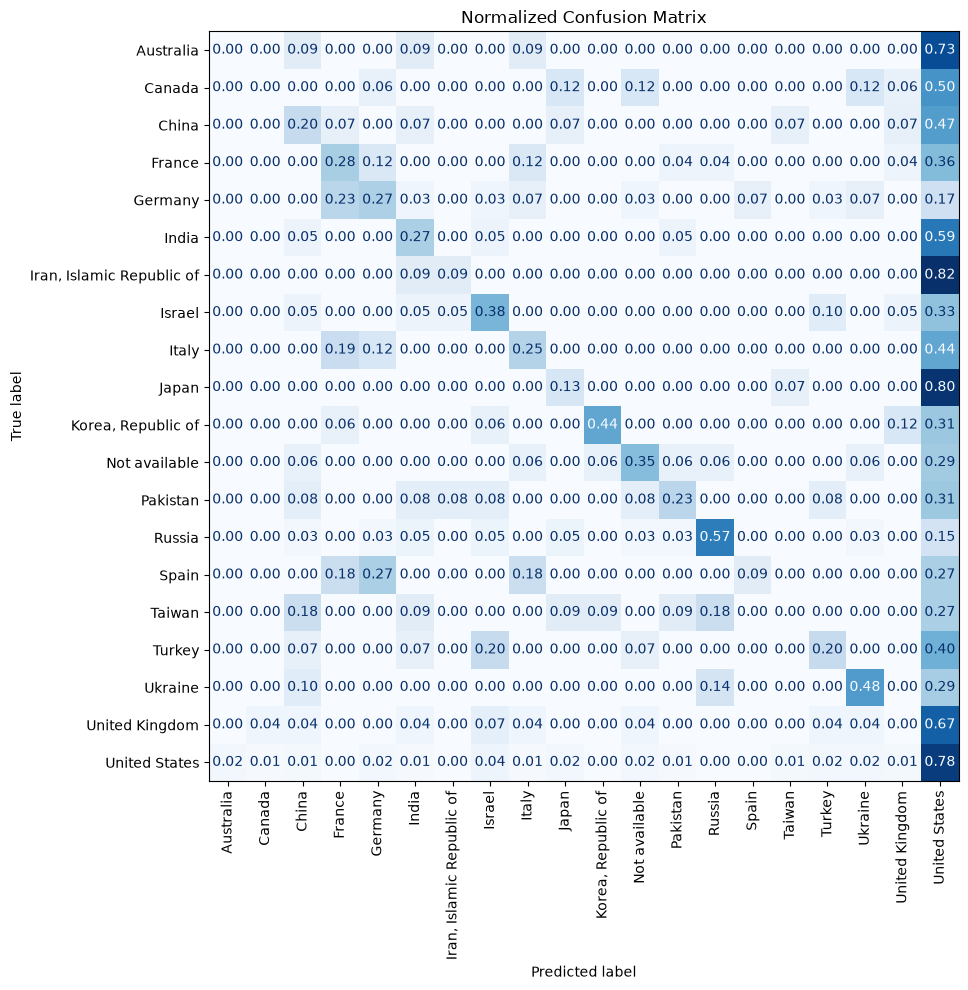

In [21]:
# Confusion matrix
cm = confusion_matrix(
    true_labels_A,
    pred_labels_A,
    labels=le.classes_
)

# Plot
cm_norm = confusion_matrix(
    true_labels_A,
    pred_labels_A,
    labels=le.classes_,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    ax=ax,
    colorbar=False,
    values_format=".2f"
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

(507, 106, 20)
                                               feature  importance
1                       affected_third_countries_value    0.583551
0                              affected_entities_value    0.400707
86                  offline_conflict_intensity_Unknown    0.287405
14                             initiator_country_China    0.212492
90   functional_impact_No_system_interference_disru...    0.204405
87       offline_conflict_intensity_Yes_HIIK_intensity    0.194607
91                     functional_impact_Not_available    0.192354
101                                         Data_theft    0.189901
46                    initiator_country_Not_attributed    0.184996
85                        cyber_conflict_issue_Unknown    0.184938
76            cyber_conflict_issue_International_power    0.181796
103                              Hijacking_with_Misuse    0.177330
71                           initiator_country_Unknown    0.168189
97                   intelligence_impact_Not_av

/Users/heather.iriye/Library/CloudStorage/OneDrive-KarolinskaInstitutet/Documents/GitHub/eurepoc_cyber_security-/venv/lib/python3.14/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


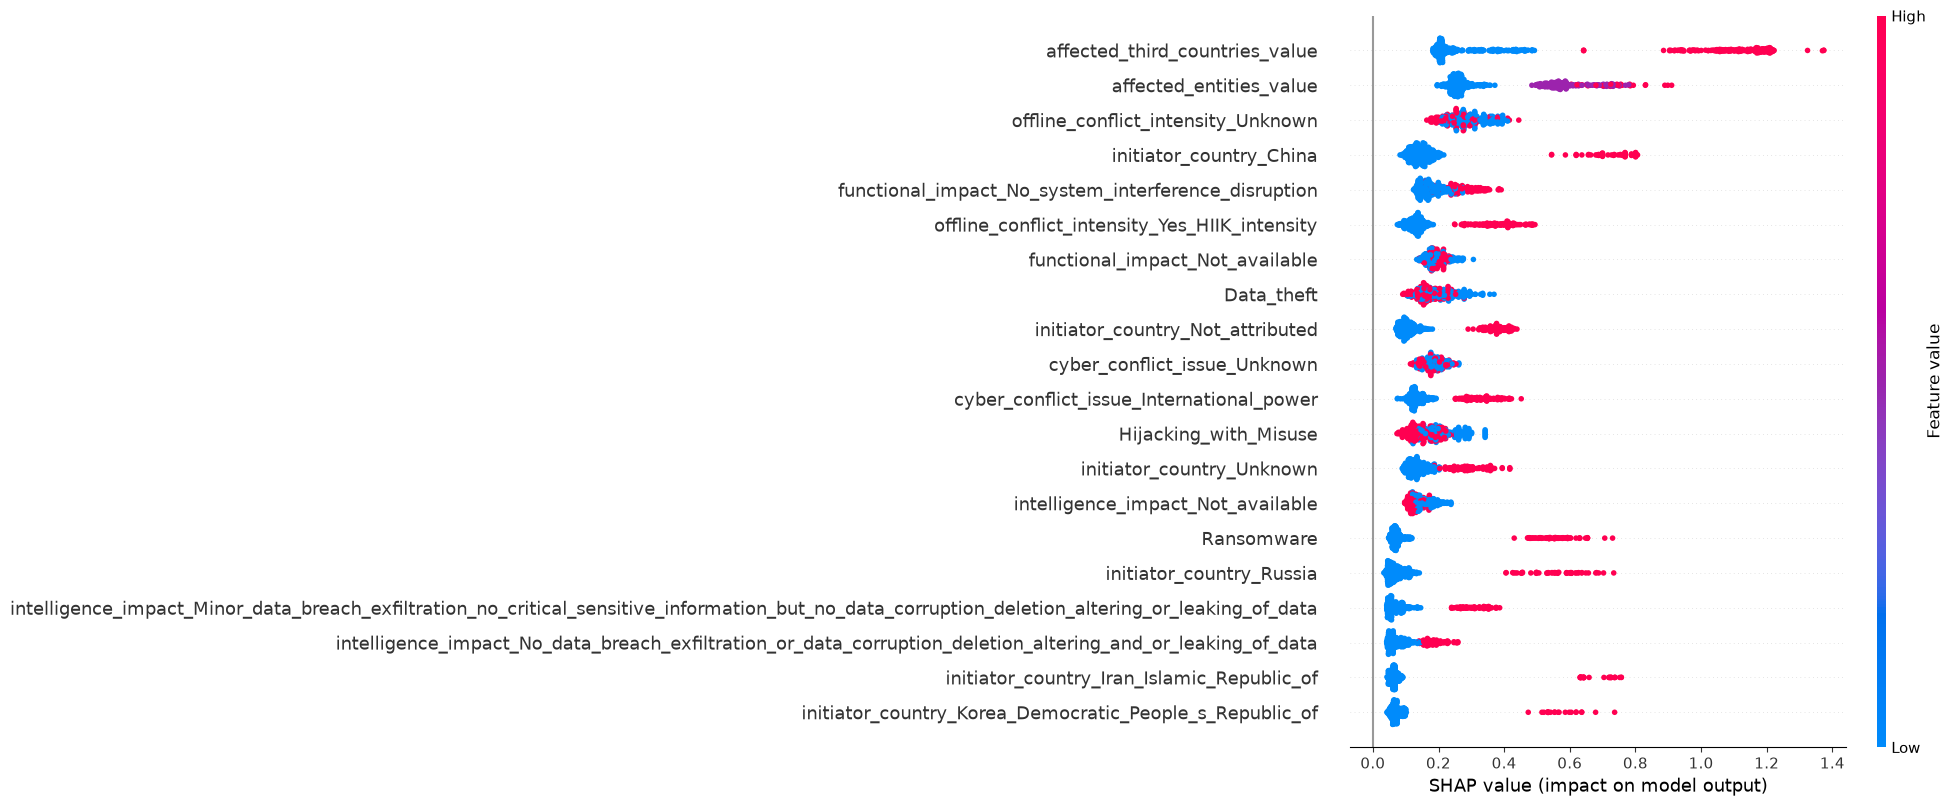

In [ ]:
# Assess feature importance
explainer = shap.TreeExplainer(xgbA)
shap_values = explainer.shap_values(X_test_A)
print(shap_values.shape)

mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

shap_importance = pd.DataFrame({
    "feature": X_test_A.columns,
    "importance": mean_abs_shap
}).sort_values(
    "importance",
    ascending=False
)

print(shap_importance.head(20))

shap.summary_plot(
    np.abs(shap_values).mean(axis=2),
    X_test_A
)